In [4]:
# 🌍 Weather Trend Forecasting — Global Climate Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

#load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

#first look at the data 
print("Shape:", df.shape)
print("\nColumn:", df.columns.tolist())
print("\nFirst 5 rows: ")
df.head()

Shape: (133123, 41)

Column: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

First 5 rows: 


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [5]:
#Data Cleaning 
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

#Convert last_updated to datetime
df["last_updated"] = pd.to_datetime(df["last_updated"])

#check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

#Basics statistics
print("\nBasic Statistics:")
df.describe()

Missing values per column:
country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone    

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,133123.000000,133123.000000,1.331230e+05,133123,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,...,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000
mean,19.206624,21.966628,1.745473e+09,2025-04-24 07:45:17.625053,21.320425,70.378536,8.027937,12.923309,168.915387,1014.066239,...,18.273698,464.292521,58.229691,15.058174,10.430491,24.297928,48.581662,1.701952,2.612238,49.669050
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.960000,-6.836100,1.730711e+09,2024-11-04 12:00:00,16.000000,60.800000,3.800000,6.100000,80.000000,1010.000000,...,10.300000,205.300000,38.000000,1.665000,1.110000,7.050000,9.990000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.745485e+09,2025-04-24 11:00:00,24.000000,75.200000,6.700000,10.800000,161.000000,1014.000000,...,15.400000,296.000000,55.000000,5.550000,2.405000,14.245000,20.050000,1.000000,2.000000,49.000000
75%,40.400000,50.231100,1.760255e+09,2025-10-12 09:45:00,28.000000,82.400000,11.000000,17.600000,256.000000,1018.000000,...,24.200000,462.850000,74.000000,17.500000,8.350000,27.935000,41.625000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.775111e+09,2026-04-02 19:30:00,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.417912,65.787481,1.709470e+07,NaN,9.703701,17.466523,7.250624,11.665587,103.687684,10.416962,...,13.860004,762.696494,30.853447,23.819782,35.928498,37.090927,150.017866,0.942828,2.450437,35.078732


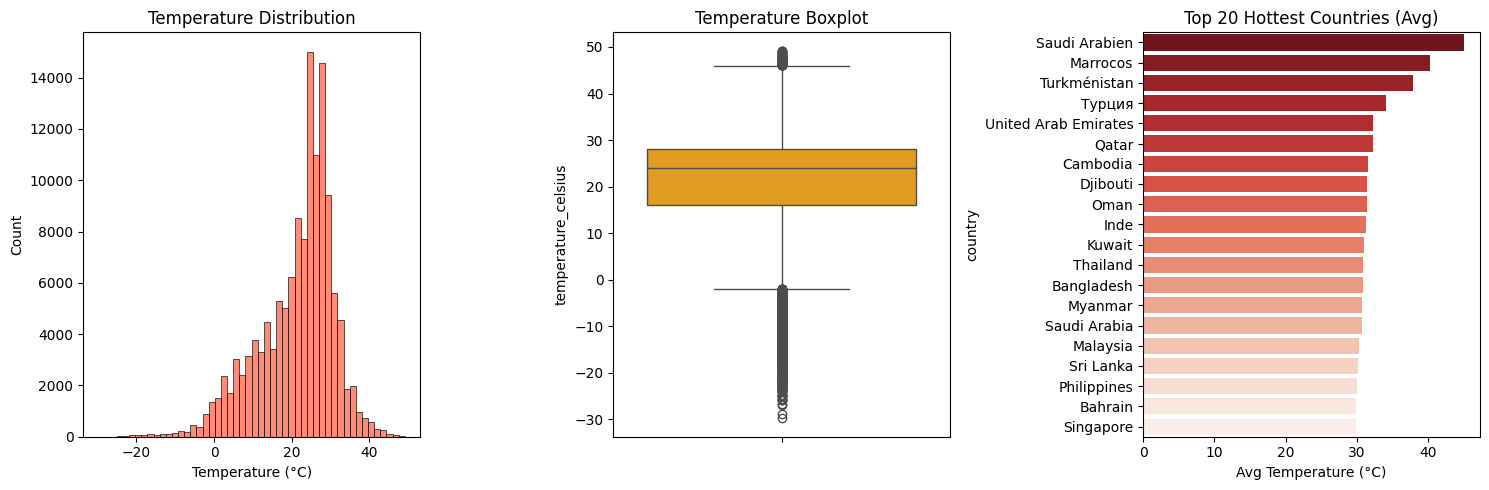

In [6]:
#Temperature Distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df["temperature_celsius"], bins=50, color="tomato")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")

plt.subplot(1, 3, 2)
sns.boxplot(df["temperature_celsius"], color="orange")
plt.title("Temperature Boxplot")

plt.subplot(1, 3, 3)
#Average temperature by country the (top 20)
top_countries = df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(20)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r")
plt.title("Top 20 Hottest Countries (Avg)")
plt.xlabel("Avg Temperature (°C)")

plt.tight_layout()
plt.show()

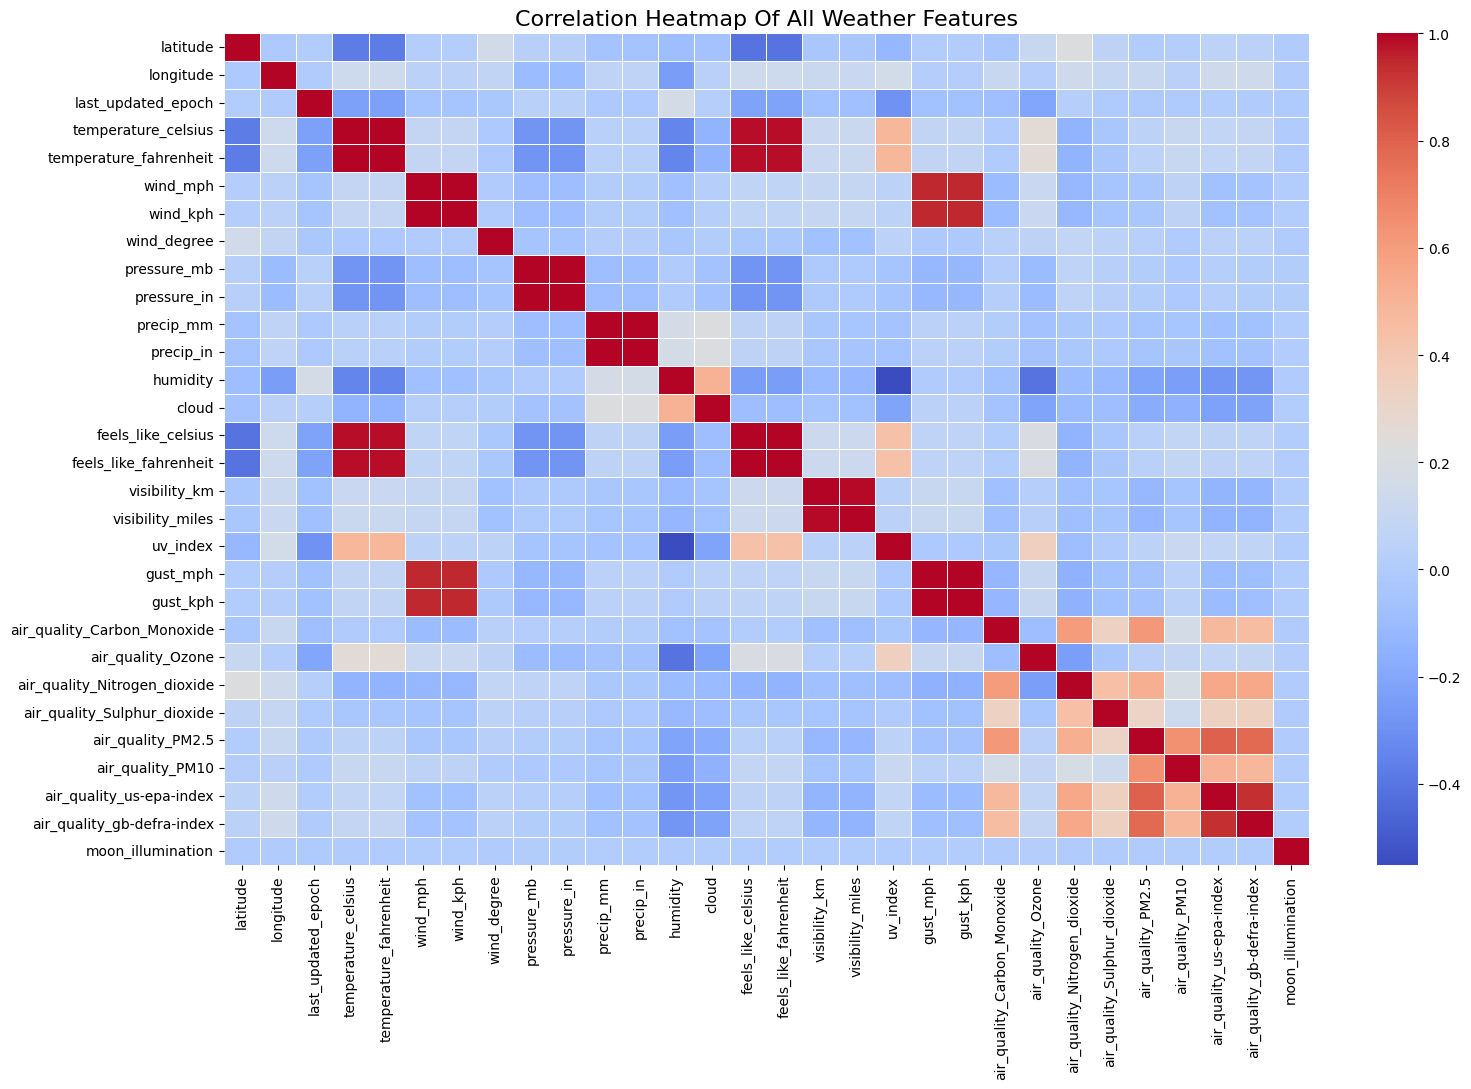

In [7]:
#Correlation Heatmap
plt.figure(figsize=(16, 11))

#select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

#Plot heatmap
sns.heatmap(numeric_df.corr(),
            annot=False,
            cmap="coolwarm",
            linewidth=0.5)

plt.title("Correlation Heatmap Of All Weather Features", fontsize=16)
plt.tight_layout()
plt.show()

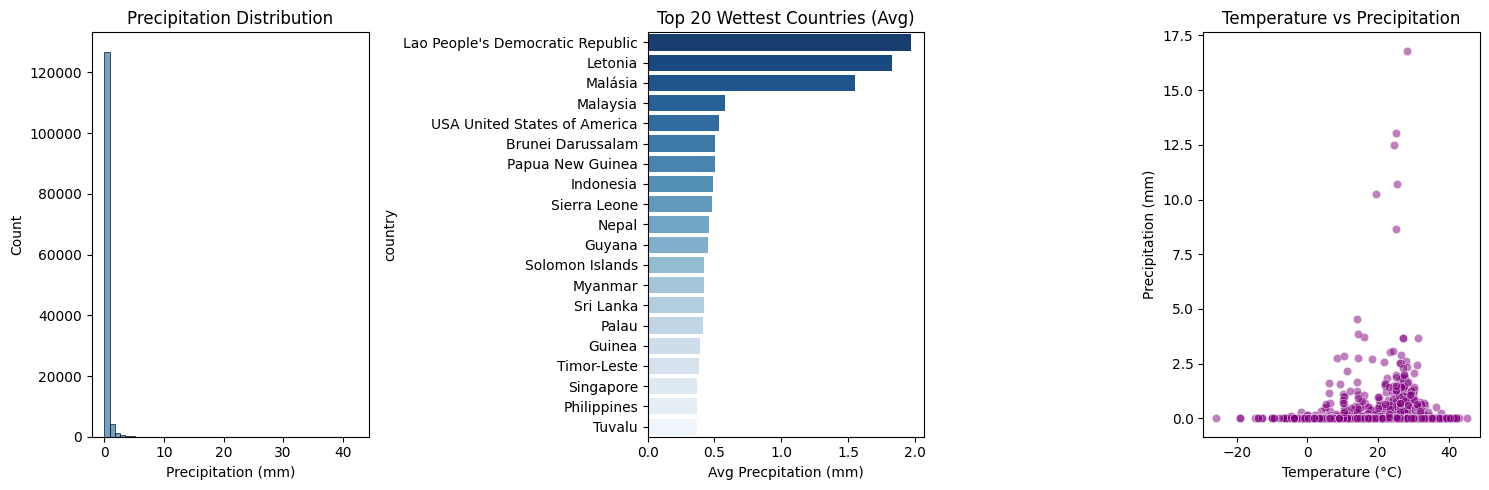

In [8]:
#Precipitation Analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3,1)
sns.histplot(df["precip_mm"], bins=50, color="steelblue")
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")

plt.subplot(1, 3, 2)
#Average precipitation by country (Top 20)
top_precip= df.groupby("country")["precip_mm"].mean().sort_values(ascending=False).head(20)
sns.barplot (x=top_precip.values, y=top_precip.index, palette="Blues_r")
plt.title("Top 20 Wettest Countries (Avg)")
plt.xlabel("Avg Precpitation (mm)")

plt.subplot(1, 3, 3)
#Temperature vs Precipitation Scatter
sns.scatterplot(data=df.sample(2000),
                x="temperature_celsius",
                y="precip_mm",
                alpha=0.5,
                color="purple"    
                )
plt.title("Temperature vs Precipitation")
plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")

plt.tight_layout()
plt.show()

Anomaly counts:
anomaly_label
Normal     126466
Anomaly      6657
Name: count, dtype: int64


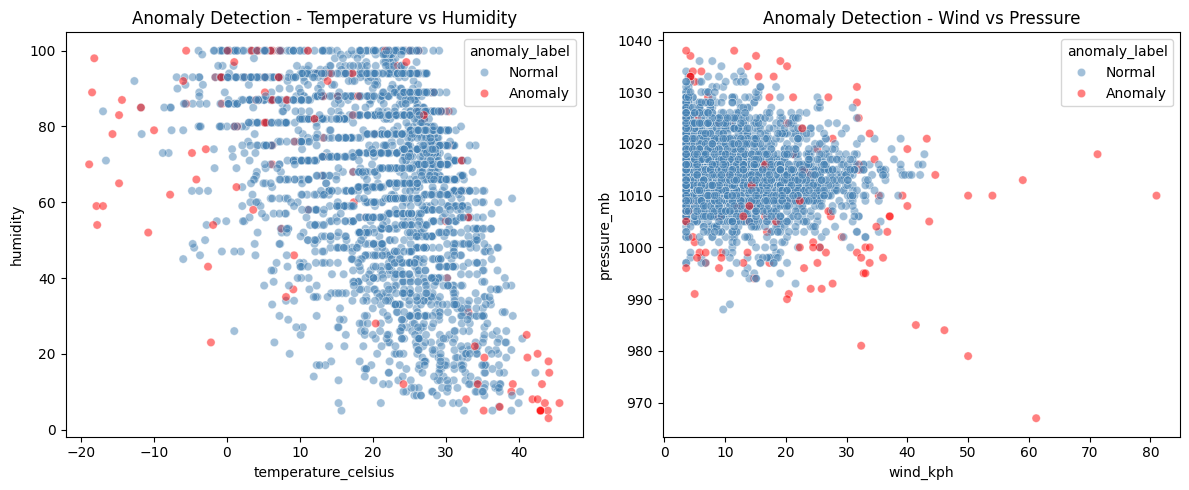

In [9]:
# Anomaly Detection using Isolation Forest
from sklearn.ensemble import IsolationForest

# Select features for anomaly detection
features = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_kph', 'pressure_mb']

# Drop rows with missing values in these columns
anomaly_df = df[features].dropna()

# Build Isolation Forest model
model = IsolationForest(contamination=0.05, random_state=42)
anomaly_df = anomaly_df.copy()
anomaly_df['anomaly'] = model.fit_predict(anomaly_df[features])

# -1 = anomaly, 1 = normal
anomaly_df['anomaly_label'] = anomaly_df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print("Anomaly counts:")
print(anomaly_df['anomaly_label'].value_counts())

# Visualize anomalies
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=anomaly_df.sample(3000), 
                x='temperature_celsius', 
                y='humidity',
                hue='anomaly_label',
                palette={'Normal': 'steelblue', 'Anomaly': 'red'},
                alpha=0.5)
plt.title('Anomaly Detection - Temperature vs Humidity')

plt.subplot(1, 2, 2)
sns.scatterplot(data=anomaly_df.sample(3000),
                x='wind_kph',
                y='pressure_mb',
                hue='anomaly_label',
                palette={'Normal': 'steelblue', 'Anomaly': 'red'},
                alpha=0.5)
plt.title('Anomaly Detection - Wind vs Pressure')

plt.tight_layout()
plt.show()

Time series shape: (22250, 2)

Date range:
Start: 2024-05-16 01:45:00
End: 2026-04-02 19:30:00


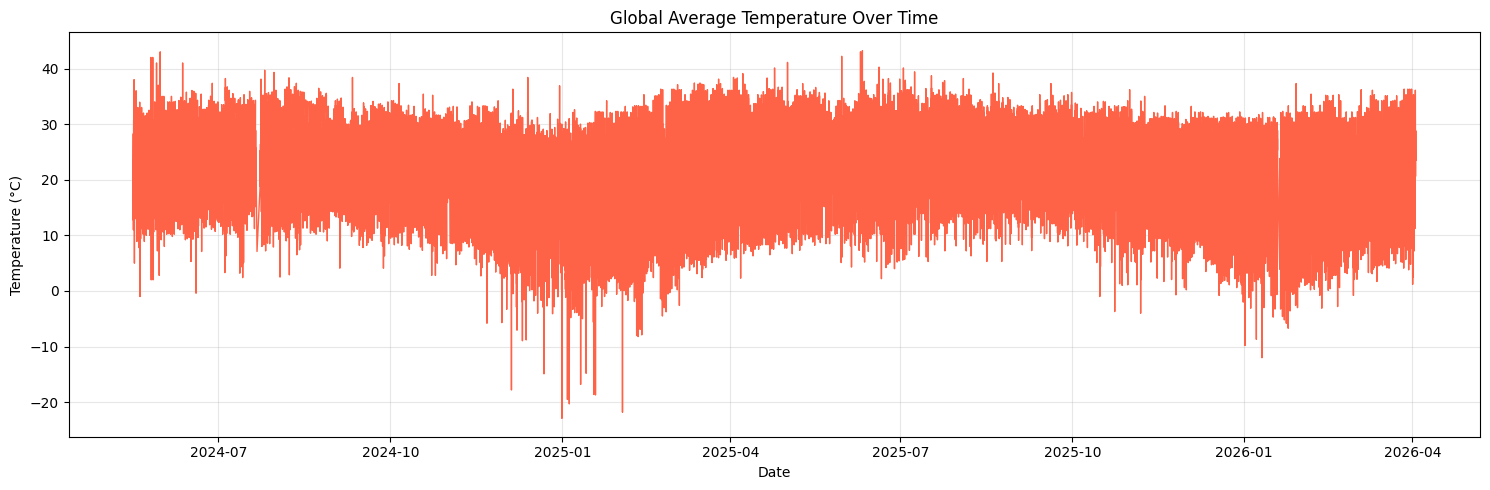

In [10]:
# Time Series Analysis
# Group by date and get average temperature
time_series = df.groupby('last_updated')['temperature_celsius'].mean().reset_index()
time_series.columns = ['date', 'temperature']
time_series = time_series.sort_values('date')

print("Time series shape:", time_series.shape)
print("\nDate range:")
print("Start:", time_series['date'].min())
print("End:", time_series['date'].max())

# Plot temperature over time
plt.figure(figsize=(15, 5))
plt.plot(time_series['date'], time_series['temperature'], 
         color='tomato', linewidth=1)
plt.title('Global Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training ARIMA model...
ARIMA MAE: 1.26
ARIMA RMSE: 1.38


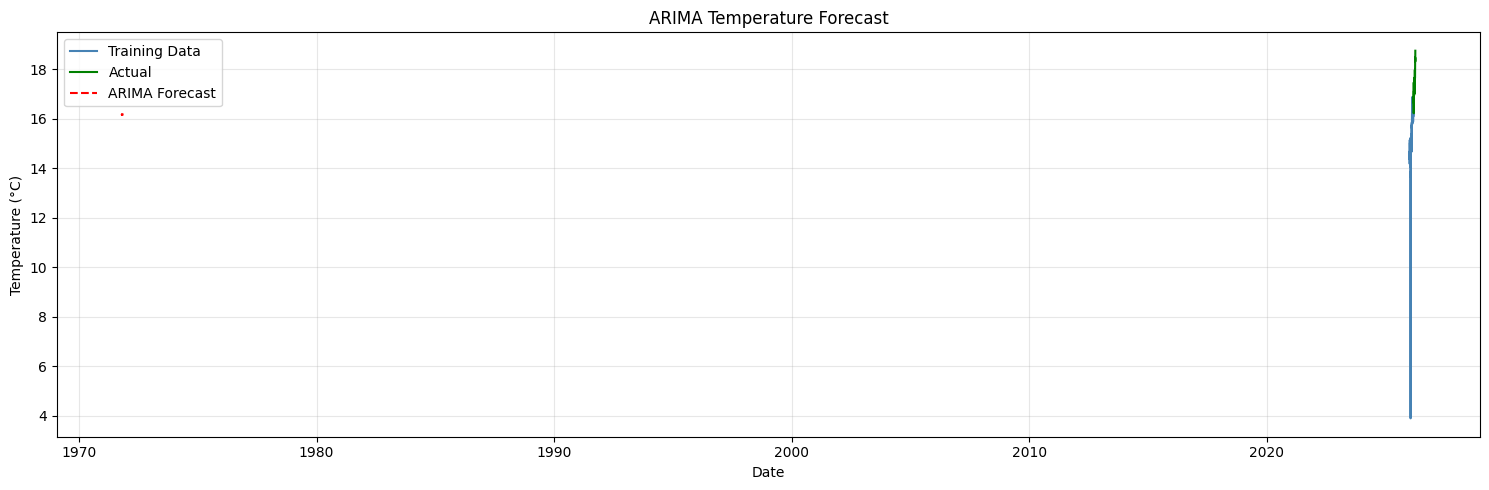

In [11]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use daily average for ARIMA
daily = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

# Train/test split - last 30 days as test
train = daily[:-30]
test = daily[-30:]

# Build ARIMA model
print("Training ARIMA model...")
arima_model = ARIMA(train, order=(5,1,0))
arima_result = arima_model.fit()

# Forecast next 30 days
forecast = arima_result.forecast(steps=30)

# Evaluate
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

# Plot
plt.figure(figsize=(15, 5))
plt.plot(train[-60:], label='Training Data', color='steelblue')
plt.plot(test, label='Actual', color='green')
plt.plot(forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training ARIMA model...
ARIMA MAE: 1.26
ARIMA RMSE: 1.39


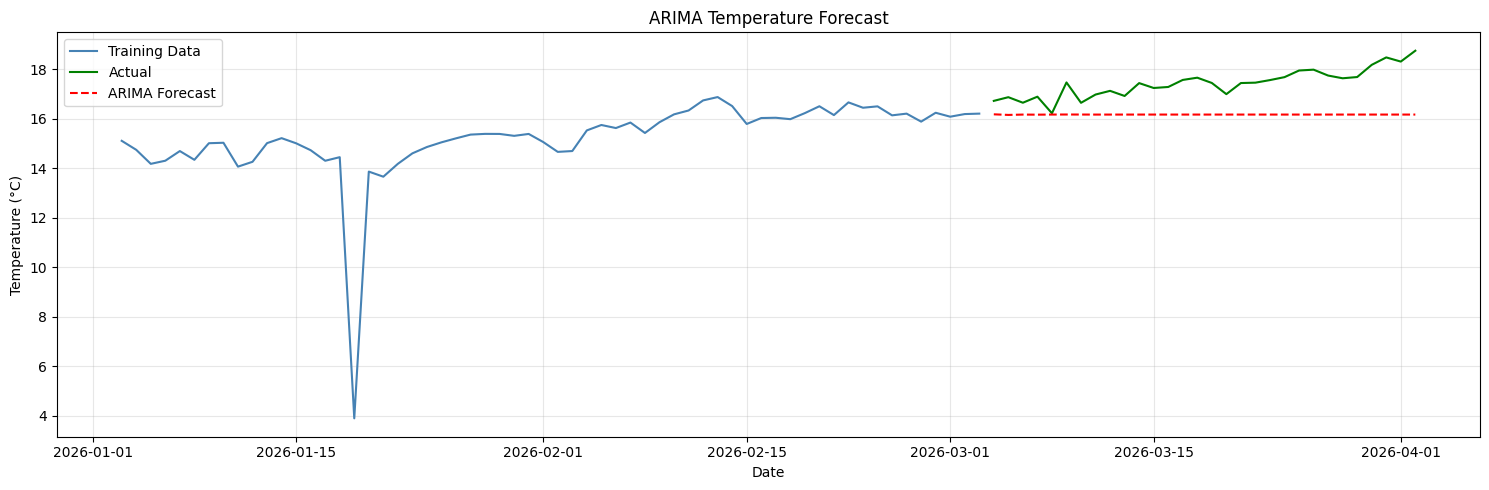

In [12]:

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use daily average with proper frequency
daily = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
daily.index = pd.to_datetime(daily.index)
daily = daily.asfreq('D', method='ffill')  # set daily frequency
daily = daily.sort_index()

# Train/test split
train = daily[:-30]
test = daily[-30:]

# Build ARIMA model
print("Training ARIMA model...")
arima_model = ARIMA(train, order=(5,1,0))
arima_result = arima_model.fit()

# Forecast
forecast = arima_result.forecast(steps=30)
forecast.index = test.index  # align dates

# Evaluate
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

# Plot
plt.figure(figsize=(15, 5))
plt.plot(train[-60:], label='Training Data', color='steelblue')
plt.plot(test, label='Actual', color='green')
plt.plot(forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Training Prophet model...


14:25:08 - cmdstanpy - INFO - Chain [1] start processing
14:25:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.74
Prophet RMSE: 0.82


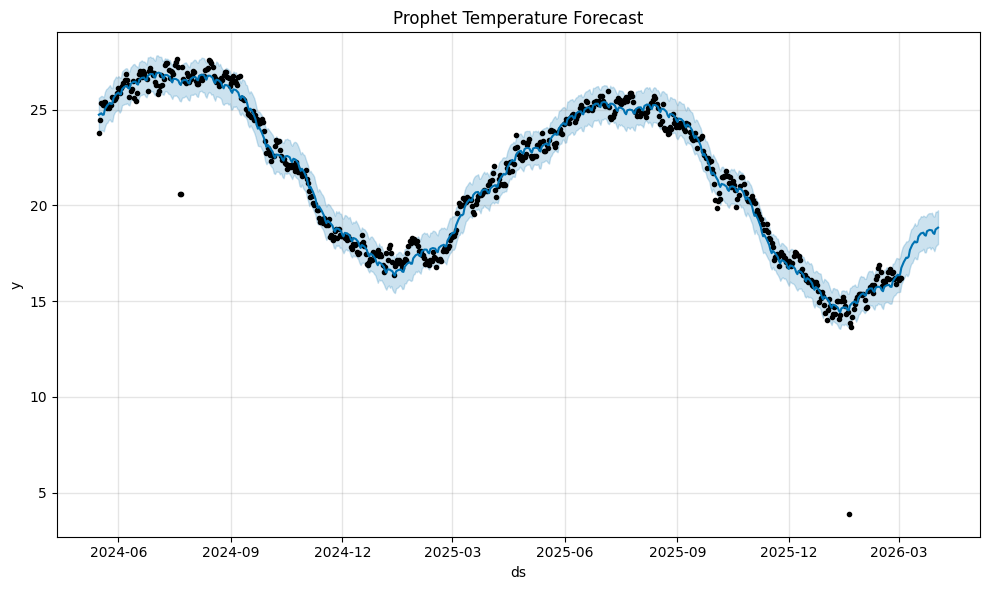

In [13]:
from prophet import Prophet

# Prepare data for Prophet (requires columns 'ds' and 'y')
prophet_df = daily.reset_index()
prophet_df.columns = ['ds', 'y']

# Split
train_prophet = prophet_df[:-30]
test_prophet = prophet_df[-30:]

# Build Prophet model
print("Training Prophet model...")
prophet_model = Prophet(daily_seasonality=True, 
                        yearly_seasonality=True,
                        weekly_seasonality=True)
prophet_model.fit(train_prophet)

# Forecast
future = prophet_model.make_future_dataframe(periods=30)
forecast_prophet = prophet_model.predict(future)

# Evaluate
predicted = forecast_prophet[-30:]['yhat'].values
actual = test_prophet['y'].values
mae_prophet = mean_absolute_error(actual, predicted)
rmse_prophet = np.sqrt(mean_squared_error(actual, predicted))
print(f"Prophet MAE: {mae_prophet:.2f}")
print(f"Prophet RMSE: {rmse_prophet:.2f}")

# Plot
prophet_model.plot(forecast_prophet)
plt.title('Prophet Temperature Forecast')
plt.tight_layout()
plt.show()


Building Ensemble Model...
Ensemble MAE: 0.30
Ensemble RMSE: 0.37

--- Model Comparison ---
ARIMA   → MAE: 1.26  RMSE: 1.39
Prophet → MAE: 0.74  RMSE: 0.82
Ensemble→ MAE: 0.30  RMSE: 0.37


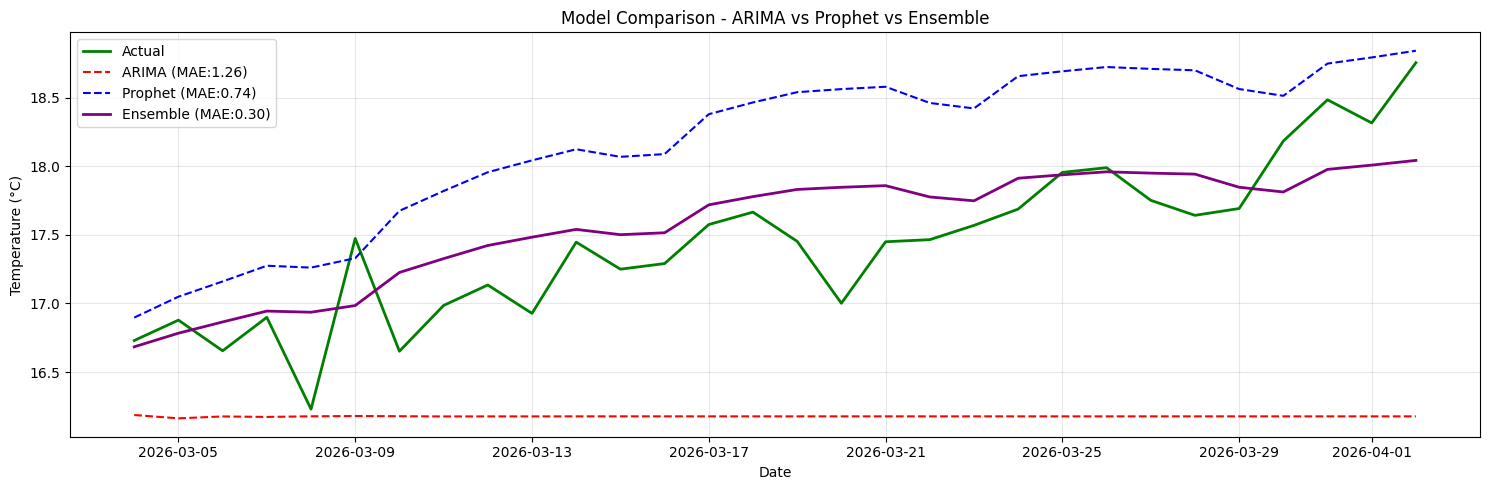

In [14]:
# Ensemble Model - combine ARIMA and Prophet
print("Building Ensemble Model...")

# Get Prophet predictions for last 30 days
prophet_pred = forecast_prophet[-30:]['yhat'].values

# Get ARIMA predictions for last 30 days
arima_pred = forecast.values

# Ensemble = weighted average (Prophet gets more weight since it performed better)
ensemble_pred = (0.3 * arima_pred) + (0.7 * prophet_pred)

# Evaluate ensemble
mae_ensemble = mean_absolute_error(test.values, ensemble_pred)
rmse_ensemble = np.sqrt(mean_squared_error(test.values, ensemble_pred))
print(f"Ensemble MAE: {mae_ensemble:.2f}")
print(f"Ensemble RMSE: {rmse_ensemble:.2f}")

# Compare all models
print("\n--- Model Comparison ---")
print(f"ARIMA   → MAE: 1.26  RMSE: 1.39")
print(f"Prophet → MAE: {mae_prophet:.2f}  RMSE: {rmse_prophet:.2f}")
print(f"Ensemble→ MAE: {mae_ensemble:.2f}  RMSE: {rmse_ensemble:.2f}")

# Plot comparison
plt.figure(figsize=(15, 5))
plt.plot(test.index, test.values, label='Actual', color='green', linewidth=2)
plt.plot(test.index, arima_pred, label=f'ARIMA (MAE:{1.26})', color='red', linestyle='--')
plt.plot(test.index, prophet_pred, label=f'Prophet (MAE:{mae_prophet:.2f})', color='blue', linestyle='--')
plt.plot(test.index, ensemble_pred, label=f'Ensemble (MAE:{mae_ensemble:.2f})', color='purple', linewidth=2)
plt.title('Model Comparison - ARIMA vs Prophet vs Ensemble')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Building Feature Importance Model...


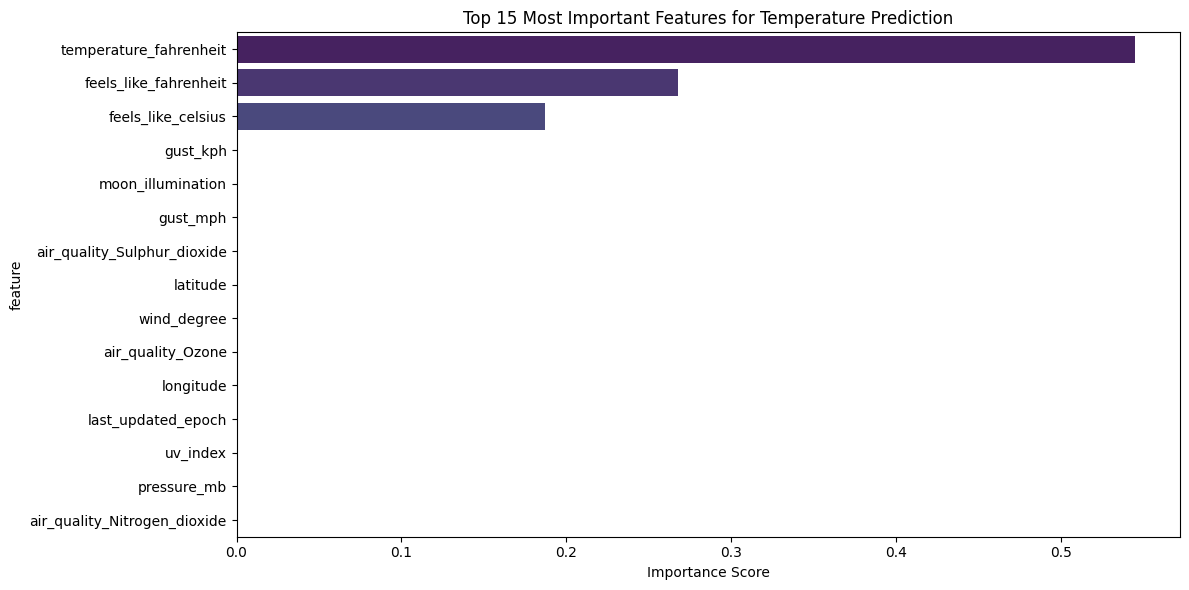


Top 5 most important features:
                   feature  importance
3   temperature_fahrenheit    0.545097
14   feels_like_fahrenheit    0.267921
13      feels_like_celsius    0.186923
19                gust_kph    0.000008
28       moon_illumination    0.000005


In [15]:
from sklearn.ensemble import RandomForestRegressor
import shap

# Feature Importance
print("Building Feature Importance Model...")

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable
features_cols = [col for col in numeric_cols if col != 'temperature_celsius']

# Prepare data
X = df[features_cols].dropna()
y = df.loc[X.index, 'temperature_celsius']

# Sample for speed
X_sample = X.sample(5000, random_state=42)
y_sample = y.loc[X_sample.index]

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_sample, y_sample)

# Plot Feature Importance
importance_df = pd.DataFrame({
    'feature': features_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features for Temperature Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head())


In [16]:
import folium
from IPython.display import display

# Average temperature by location
geo_df = df.groupby(['country', 'location_name', 'latitude', 'longitude']).agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'precip_mm': 'mean'
}).reset_index()

# Create map
weather_map = folium.Map(location=[20, 0], zoom_start=2, 
                         tiles='https://tile.openstreetmap.org/{z}/{x}/{y}.png',
                         attr='OpenStreetMap')

# Add circles for each location
for _, row in geo_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='red' if row['temperature_celsius'] > 25 else 'blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['location_name']}, {row['country']}<br>Avg Temp: {row['temperature_celsius']:.1f}°C<br>Humidity: {row['humidity']:.1f}%"
    ).add_to(weather_map)

# Save map
weather_map.save('weather_map.html')
print("Map saved as weather_map.html!")
print(f"Total locations mapped: {len(geo_df)}")


Map saved as weather_map.html!
Total locations mapped: 457


Available air quality columns: ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10']


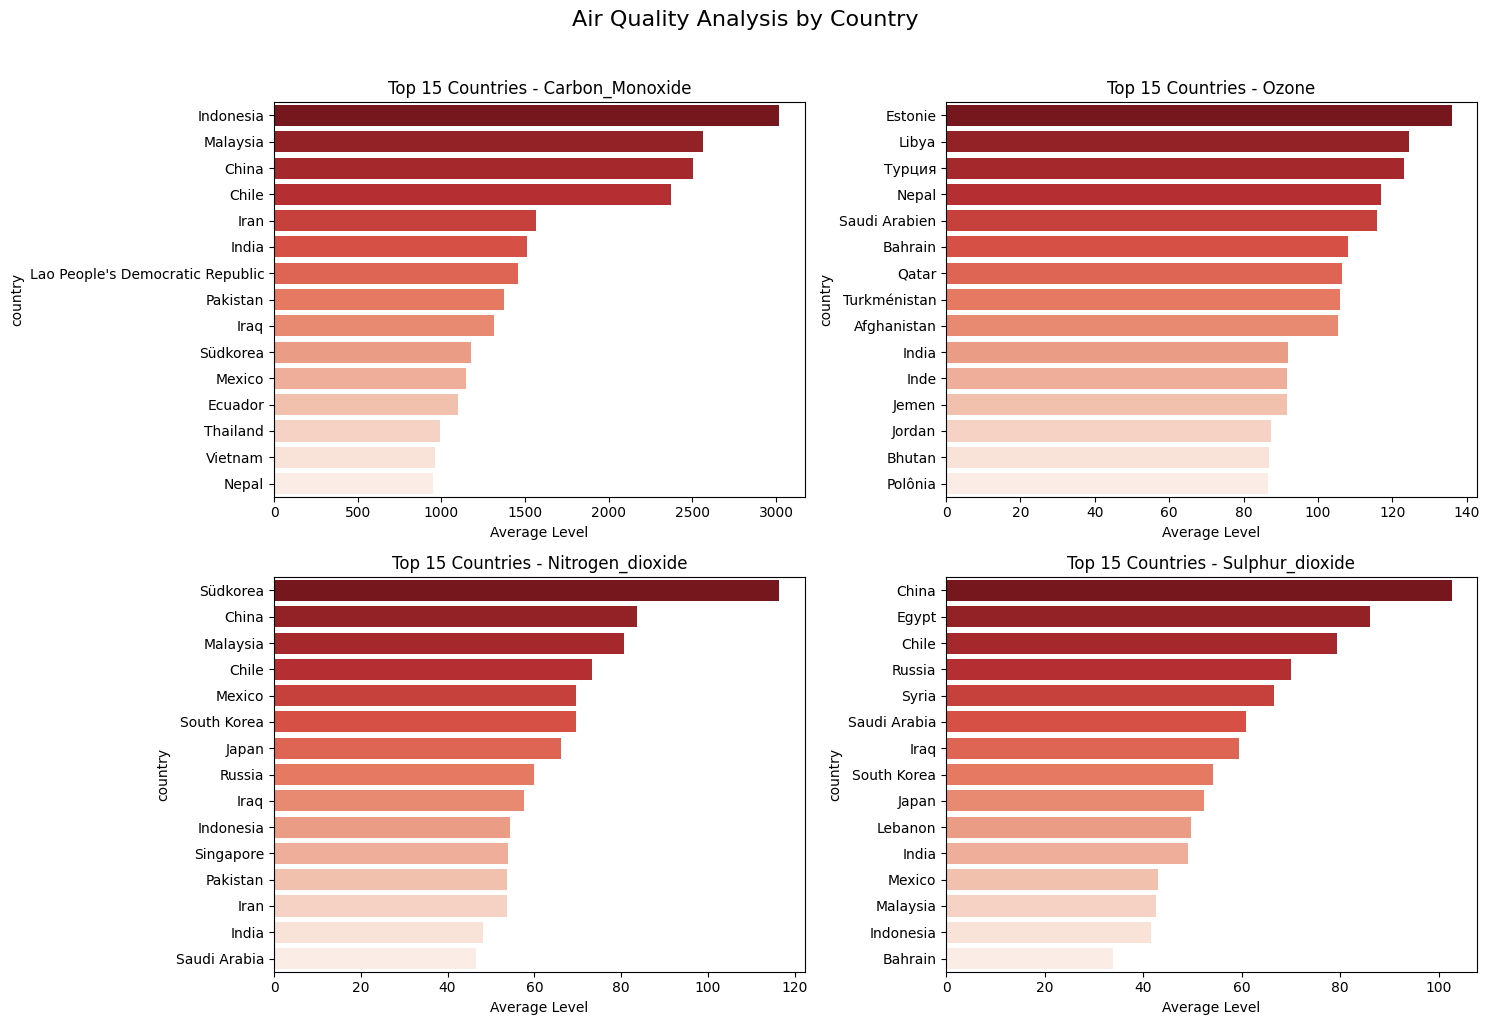


Correlation between Air Quality and Temperature:
Carbon_Monoxide: -0.005
Ozone: 0.259
Nitrogen_dioxide: -0.144
Sulphur_dioxide: -0.036
PM2.5: 0.052
PM10: 0.106


In [17]:
# Air Quality Analysis
air_quality_cols = ['air_quality_Carbon_Monoxide', 
                    'air_quality_Ozone',
                    'air_quality_Nitrogen_dioxide',
                    'air_quality_Sulphur_dioxide',
                    'air_quality_PM2.5',
                    'air_quality_PM10']

# Check which air quality columns exist in our dataset
available_aq = [col for col in air_quality_cols if col in df.columns]
print("Available air quality columns:", available_aq)

# Average air quality by country (top 20 most polluted)
plt.figure(figsize=(15, 10))

for i, col in enumerate(available_aq[:4], 1):
    plt.subplot(2, 2, i)
    top_polluted = df.groupby('country')[col].mean().sort_values(ascending=False).head(15)
    sns.barplot(x=top_polluted.values, y=top_polluted.index, palette='Reds_r')
    plt.title(f'Top 15 Countries - {col.replace("air_quality_", "")}')
    plt.xlabel('Average Level')

plt.suptitle('Air Quality Analysis by Country', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Correlation between air quality and temperature
print("\nCorrelation between Air Quality and Temperature:")
for col in available_aq:
    corr = df[col].corr(df['temperature_celsius'])
    print(f"{col.replace('air_quality_', '')}: {corr:.3f}")